

<div style="text-align: right"><i> </i></div>

***
<center><h1> Analysing the Macaronesian Zooplankton and Micronekton </h1></center>

***


# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Set up Python](#2.-Set-up-Python)
- [3. Data](#3.-Data)
    - [3.1 Presentation of the product used](#3.1-Presentation-of-the-product-used)
    - [3.2 Accessing the data](#3.2-Accessing-the-data)
- [4. Spatial variability of zooplankton and micronekton](#4.-Spatial-variability-of-zooplankton-and-micronekton)
- [5. Long Term Trends in the Area of Macaronesia](#5.-Long-Term-Trends-in-the-Area-of-Macaronesia)


# 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

The notebook analyses the zooplankton a and micronekton in the European Macaronesia Area.

 We analyse these variables spatially, and see what are the long-term trends associated with them.

# 2. Set up Python

[Go back to the "Table of contents"](#Table-of-contents)

In [2]:
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import datetime
import pandas as pd
import os

from scipy.stats import linregress, pearsonr
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 3. Data

[Go back to the "Table of contents"](#Table-of-contents)

## 3.1 Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)


----------------
Product used 
Global ocean low and mid trophic levels biomass content hindcast
https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_BGC_001_033/description

**Overview**

The Low and Mid-Trophic Levels (LMTL) reanalysis for global ocean is produced at CLS on behalf of Global Ocean Marine Forecasting Center. It provides 2D fields of biomass content of zooplankton and six functional groups of micronekton. It uses the LMTL component of SEAPODYM dynamical population model (http://www.seapodym.eu). No data assimilation has been done. This product also contains forcing data: net primary production, euphotic depth, depth of each pelagic layers zooplankton and micronekton inhabit, average temperature and currents over pelagic layers.

**Forcings sources:**

- Ocean currents and temperature (CMEMS multiyear product)
- Net Primary Production computed from chlorophyll a, Sea Surface Temperature and Photosynthetically Active Radiation observations (chlorophyll from CMEMS multiyear product, SST from NOAA NCEI AVHRR-only Reynolds, PAR from INTERIM) and relaxed by model outputs at high latitudes (CMEMS biogeochemistry multiyear product)

**Vertical coverage:**

- Epipelagic layer
- Upper mesopelagic layer
- Lower mesopelagic layer (max. 1000m)

**DOI (product):**
https://doi.org/10.48670/moi-00020

**References:**

- Lehodey P., Murtugudde R., Senina I. (2010). Bridging the gap from ocean models to population dynamics of large marine predators: a model of mid-trophic functional groups. Progress in Oceanography, 84, p. 69-84.
- Lehodey, P., Conchon, A., Senina, I., Domokos, R., Calmettes, B., Jouanno, J., Hernandez, O., Kloser, R. (2015) Optimization of a micronekton model with acoustic data. ICES Journal of Marine Science, 72(5), p. 1399-1412.
- Conchon A. (2016). Modélisation du zooplancton et du micronecton marins. Thèse de Doctorat, Université de La Rochelle, 136 p.



**Classification**

Full name: Global ocean low and mid trophic levels biomass content hindcast
Product ID: GLOBAL_MULTIYEAR_BGC_001_033
Source: Numerical models
Spatial extent: Global OceanLat -80° to 89.92°Lon -180° to 179.92°
Spatial resolution: 0.083° × 0.083°
Temporal extent: 31 Dec 1997 to 30 Dec 2023
Temporal resolution: Daily
Elevation (depth) levels: 3
Processing level: Level 4
Variables: Eastward sea water velocity vertical mean over pelagic layerEuphotic zone depthMass content of epipelagic micronekton expressed as wet weight in sea waterMass content of highly migrant lower mesopelagic micronekton expressed as wet weight in sea waterMass content of lower mesopelagic micronekton expressed as wet weight in sea waterMass content of migrant lower mesopelagic micronekton expressed as wet weight in sea waterMass content of migrant upper mesopelagic micronekton expressed as wet weight in sea waterMass content of upper mesopelagic micronekton expressed as wet weight in sea waterMass content of zooplankton expressed as carbon in sea waterNet primary productivity of biomass expressed as carbon in sea waterNorthward sea water velocity vertical mean over pelagic layerSea water pelagic layer bottom depthSea water potential temperature vertical mean over pelagic layer
Update frequency: Annually
Format: NetCDF-4
Originating centre: Mercator Ocean International
Last metadata update: 26 November 2024

The table below summarizes the main characteristics of the dataset :

| Parameter | Value |
| :---: | :---|
| **Variables used** | zooc, mknc|
| **Product identifier** |[GLOBAL_MULTIYEAR_BGC_001_033](https://data.marine.copernicus.eu/product/GLOBAL_ANALYSISFORECAST_BGC_001_028/description) |
| **Spatial resolution** | 0.083° × 0.083° |
| **Temporal resolution** | Daily |
| **Temporal coverage** | 01 Jan 1998 to 31 Dec 2024 |





**More detailed information about the product in:** [Product User Manual (PUM)](https://documentation.marine.copernicus.eu/PUM/CMEMS-GLO-PUM-001-033.pdf)


**More information about the quality of the product in:** [Quality Information Document (QUID)](https://documentation.marine.copernicus.eu/QUID/CMEMS-GLO-QUID-001-033.pdf)

## 3.2 Accessing the data
[Go back to the "Table of contents"](#Table-of-contents)

In [3]:
import copernicusmarine

**Coordinates AREA**

In [4]:
# In this sell, we define the boundaries of our area of interest

lat_min = 25
lat_max = 41
lon_min = -33
lon_max = -12



***Coordinates AZORES***

In [5]:
lat_minAzores = 35
lat_maxAzores = 41
lon_minAzores = -33
lon_maxAzores = -21

***Coordinates MADEIRA***

In [6]:
lat_minMadeira = 31
lat_maxMadeira = 35
lon_minMadeira = -21
lon_maxMadeira = -13

***Coordinates CANARY ISLANDS***

In [7]:
lat_minCanary = 26
lat_maxCanary = 31
lon_minCanary = -21
lon_maxCanary = -12

In [33]:
import copernicusmarine

copernicusmarine.subset(
  dataset_id="cmems_mod_glo_bgc_my_0.083deg-lmtl_P1D-i",
  variables=["zooc", "mnkc_epi"],
  minimum_longitude=-33,
  maximum_longitude=-12,
  minimum_latitude=25,
  maximum_latitude=41,
  start_datetime="1998-01-01T00:00:00",
  end_datetime="2024-12-31T00:00:00",
  output_filename = "ZooMicronektonMacaronesian_Jan1998_Dic2024_07Feb2026.nc",
  output_directory = "copernicus-data"
)

INFO - 2026-02-07T22:40:20Z - Selected dataset version: "202511"
INFO - 2026-02-07T22:40:20Z - Selected dataset part: "default"
INFO - 2026-02-07T22:40:24Z - Starting download. Please wait...


  0%|          | 0/144 [00:00<?, ?it/s]

INFO - 2026-02-07T22:49:17Z - Successfully downloaded to copernicus-data\ZooMicronektonMacaronesian_Jan1998_Dic2024_07Feb2026.nc


ResponseSubset(file_path=WindowsPath('copernicus-data/ZooMicronektonMacaronesian_Jan1998_Dic2024_07Feb2026.nc'), output_directory=WindowsPath('copernicus-data'), filename='ZooMicronektonMacaronesian_Jan1998_Dic2024_07Feb2026.nc', file_size=1828.4729694656487, data_transfer_size=9618.783755725191, variables=['zooc', 'mnkc_epi'], coordinates_extent=[GeographicalExtent(minimum=-33.0, maximum=-12.0, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=25.083332061767578, maximum=41.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='1998-01-01T00:00:00+00:00', maximum='2024-12-31T00:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED')

**or**

In [12]:
ZooMicroNekMacaronesia1998_2024 = copernicusmarine.open_dataset(
dataset_id="cmems_mod_glo_bgc_my_0.083deg-lmtl_P1D-i",
 variables=["zooc","mnkc_epi"],                    
 minimum_longitude=lon_min,
 maximum_longitude=lon_max,
 minimum_latitude=lat_min,
 maximum_latitude=lat_max,
 start_datetime="1998-01-01T00:00:00",
 end_datetime="2024-12-31T00:00:00",
#output_directory = "data"
)

INFO - 2026-02-08T20:15:53Z - Selected dataset version: "202511"
INFO - 2026-02-08T20:15:53Z - Selected dataset part: "default"


In [9]:
ZooMicroNekMacaronesia1998_2024.to_netcdf("ZooMicroNekMacaronesia1998_2024.nc")

In [8]:
ds_new = xr.open_dataset('copernicus-data/ZooMicronektonMacaronesian_Jan1998_Dic2024_07Feb2026.nc')
ds_new

<xarray.Dataset> Size: 8GB
Dimensions:    (time: 9862, latitude: 192, longitude: 253)
Coordinates:
  * latitude   (latitude) float32 768B 25.08 25.17 25.25 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * time       (time) datetime64[ns] 79kB 1998-01-01 1998-01-02 ... 2024-12-31
Data variables:
    zooc       (time, latitude, longitude) float64 4GB ...
    mnkc_epi   (time, latitude, longitude) float64 4GB ...
Attributes:
    history:                   Created on 2025-09-11
    title:                     Global ocean low and mid trophic levels biomas...
    source:                    SEAPODYM-LMTL 3.0.0
    Conventions:               CF-1.7
    institution:               CLS
    references:                http://www.cls.fr; http://www.seapodym.eu
    copernicusmarine_version:  2.2.2

# 4. Spatial variability of zooplankton and micronekton
[Go back to the "Table of contents"](#Table-of-contents)

In [36]:
zoo_new = ds_new['zooc']

In [39]:
zoo_new

<xarray.DataArray 'zooc' (time: 9862, latitude: 192, longitude: 253)> Size: 4GB
[479056512 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 768B 25.08 25.17 25.25 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * time       (time) datetime64[ns] 79kB 1998-01-01 1998-01-02 ... 2024-12-31
Attributes:
    units:          g m-2
    standard_name:  mass_content_of_zooplankton_expressed_as_carbon_in_sea_water

In [40]:
necton_new = ds_new['mnkc_epi']

In [41]:
necton_new

<xarray.DataArray 'mnkc_epi' (time: 9862, latitude: 192, longitude: 253)> Size: 4GB
[479056512 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float32 768B 25.08 25.17 25.25 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * time       (time) datetime64[ns] 79kB 1998-01-01 1998-01-02 ... 2024-12-31
Attributes:
    units:          g m-2
    standard_name:  ocean_wet_mass_content_of_epipelagic_micronekton

In [ ]:
zoo_new_avg = zoo_new.groupby('time.year').mean(dim=["latitude", "longitude"])

In [ ]:
zoo_new_avg

<xarray.DataArray 'zooc' (time: 9862)> Size: 79kB
array([0.66673092, 0.68615259, 0.69511209, ..., 0.34382856, 0.56331078,
       0.6821619 ])
Coordinates:
  * time     (time) datetime64[ns] 79kB 1998-01-01 1998-01-02 ... 2024-12-31
Attributes:
    units:          g m-2
    standard_name:  mass_content_of_zooplankton_expressed_as_carbon_in_sea_water

In [63]:
zoo_new_avg_year = zoo_new_avg.groupby('time.year').mean()
zoo_new_avg_year

<xarray.DataArray 'zooc' (year: 27)> Size: 216B
array([0.36843304, 0.33340519, 0.33536055, 0.31372269, 0.33393975,
       0.40921389, 0.51387929, 0.6475945 , 0.58094502, 0.54068174,
       0.58648364, 0.66398787, 0.5200408 , 0.59867937, 0.59698503,
       0.61379341, 0.67958449, 0.75884429, 0.59310969, 0.4418268 ,
       0.66219515, 0.57709711, 0.52597107, 0.60332473, 0.52448283,
       0.52627105, 0.43114504])
Coordinates:
  * year     (year) int64 216B 1998 1999 2000 2001 2002 ... 2021 2022 2023 2024
Attributes:
    units:          g m-2
    standard_name:  mass_content_of_zooplankton_expressed_as_carbon_in_sea_water

In [53]:
necton_new_avg = necton_new.mean(dim=["latitude", "longitude"])

In [54]:
necton_new_avg

<xarray.DataArray 'mnkc_epi' (time: 9862)> Size: 79kB
array([0.93832452, 0.92250348, 0.92930591, ..., 0.90586425, 0.78256329,
       0.78323233])
Coordinates:
  * time     (time) datetime64[ns] 79kB 1998-01-01 1998-01-02 ... 2024-12-31

In [65]:
necton_new_avg_year = necton_new_avg.groupby('time.year').mean()
necton_new_avg_year

<xarray.DataArray 'mnkc_epi' (year: 27)> Size: 216B
array([0.6128436 , 0.48524196, 0.37238144, 0.25911145, 0.22628516,
       0.80696707, 1.36669664, 1.16792386, 1.38412173, 1.60939737,
       1.96403544, 0.83942459, 0.8901641 , 0.87029719, 0.74660306,
       0.67913942, 1.30667017, 1.94864396, 1.66693105, 0.89559456,
       0.89023255, 1.20512623, 1.134823  , 1.19634105, 1.4213692 ,
       1.46633813, 1.46767753])
Coordinates:
  * year     (year) int64 216B 1998 1999 2000 2001 2002 ... 2021 2022 2023 2024

**Group by seasons**

In [ ]:
ds_seas = ds_new.groupby("time.season").mean()
ds_seas

<xarray.Dataset> Size: 3MB
Dimensions:    (season: 4, latitude: 192, longitude: 253)
Coordinates:
  * latitude   (latitude) float32 768B 25.08 25.17 25.25 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    zooc       (season, latitude, longitude) float64 2MB 0.2384 ... 0.7132
    mnkc_epi   (season, latitude, longitude) float64 2MB 0.377 0.381 ... 2.335
Attributes:
    title:        Global ocean low and mid trophic levels biomass content hin...
    history:      Created on 2025-09-11
    Conventions:  CF-1.7
    institution:  CLS
    references:   http://www.cls.fr; http://www.seapodym.eu
    source:       SEAPODYM-LMTL 3.0.0

In [ ]:
season_names = {
    "DJF": "Winter",
    "MAM": "Spring",
    "JJA": "Summer",
    "SON": "Autumn"
}

In [ ]:
# display seasonal zoo patterns

f = plt.figure(figsize=(12,9))


seasons = ["DJF", "MAM", "JJA", "SON"]
seasons_name = {
    'DJF': 'Winter',
    'MAM': 'Spring',
    'JJA': 'Summer',
    'SON': 'Autumn'
}
seasons = list(seasons_name.keys())

ds_seas_coarse = ds_seas.coarsen(latitude=5, longitude=5, boundary="trim").mean()
x = ds_seas_coarse.longitude.data
y = ds_seas_coarse.latitude.data

vmin = np.nanpercentile(ds_seas["zooc"].data, 2)  # 2th percentile
vmax = np.nanpercentile(ds_seas["zooc"].data, 98)  # 98th percentile

for c, season in enumerate(seasons):

    ax = plt.subplot(2,2,c+1, projection = ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')                             # add land mask
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.9, color='gray', alpha=0.7)
    gl.right_labels = False                                                            # remove latitude labels on the right
    gl.top_labels = False 
    ax.set_ylabel('Latitude (°)')
    ax.set_ylabel('Longitude (°)')
    
    im = ax.pcolor(ds_seas["zooc"].longitude.data, ds_seas["zooc"].latitude.data, ds_seas["zooc"].sel(season=season).data, cmap='YlGn', vmin=vmin, vmax=vmax)    #, vmin=0, vmax=30
    cbar = f.colorbar(im, ax=ax,fraction=0.02, pad=0.02)                                            # add the colorbar
    cbar.set_label('Zooplankton g/$m^2$', rotation=270,fontsize=15, labelpad=25)
    ax.set_title(f'{seasons_name[season]}', fontsize=14)

#plt.savefig('fig/PercentileZooSeason1998_2024.pdf')
#plt.savefig('fig/PercentileZooSeason1998_2024.svg')
#plt.savefig('fig/PercentileZooSeason1998_2024.png')    
plt.tight_layout()

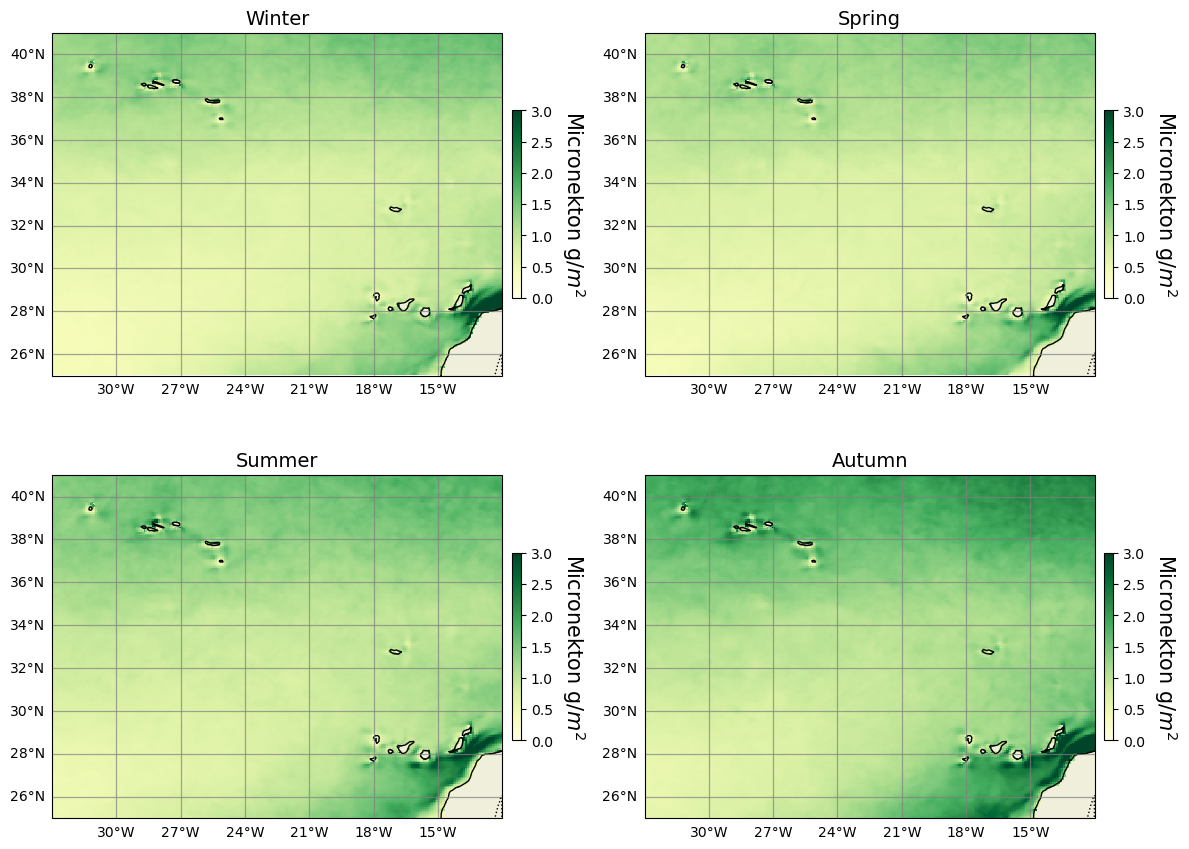

In [27]:
# display seasonal patterns

f = plt.figure(figsize=(12,9))

seasons = ["DJF", "MAM", "JJA", "SON"]
seasons_name = {
    'DJF': 'Winter',
    'MAM': 'Spring',
    'JJA': 'Summer',
    'SON': 'Autumn'
}
seasons = list(seasons_name.keys())

vmin = np.nanpercentile(ds_seas["mnkc_epi"].data, 2)  # 2th percentile
vmax = np.nanpercentile(ds_seas["mnkc_epi"].data, 98)  # 98th percentile

ds_seas_coarse = ds_seas.coarsen(latitude=5, longitude=5, boundary="trim").mean()
x = ds_seas_coarse.longitude.data
y = ds_seas_coarse.latitude.data

for c, season in enumerate(seasons):

    ax = plt.subplot(2,2,c+1, projection = ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.LAND, zorder=1, edgecolor='k')                             # add land mask
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.9, color='gray', alpha=0.7)
    gl.right_labels = False                                                            # remove latitude labels on the right
    gl.top_labels = False 
    ax.set_ylabel('Latitude (°)')
    ax.set_ylabel('Longitude (°)')
    
    im = ax.pcolor(ds_seas.longitude.data, ds_seas.latitude.data, ds_seas["mnkc_epi"].sel(season=season).data, cmap='YlGn', vmin=0, vmax=3)    #, vmin=0, vmax=30
    cbar = f.colorbar(im, ax=ax,fraction=0.02, pad=0.02)                                            # add the colorbar
    cbar.set_label('Micronekton g/$m^2$', rotation=270,fontsize=15, labelpad=25)
    ax.set_title(f'{seasons_name[season]}', fontsize=14)

plt.savefig('fig/PercentileMicronektonSeason1998_2024.pdf')
plt.savefig('fig/PercentileMicronektonSeason1998_2024.svg')
plt.savefig('fig/PercentileMicronektonSeason1998_2024.png')    
plt.tight_layout()

# 5. Long Term Trends in the Area of Macaronesia

[Go back to the "Table of contents"](#Table-of-contents)



In order to highlight long-term trends, we can smooth out the seasonal pattern of the data by resampling the monthly dataset and compute the yearly means. We use the **groupby** functions from xarray.

In [ ]:
zooc_yearly = ds_new["zooc"].groupby("time.year").mean(dim="time")
zooc_yearly

<xarray.DataArray 'zooc' (year: 27, latitude: 192, longitude: 253)> Size: 10MB
array([[[0.143179  , 0.14283137, 0.14183406, ...,        nan,
                nan,        nan],
        [0.13694441, 0.13778215, 0.13869397, ...,        nan,
                nan,        nan],
        [0.13589012, 0.13660818, 0.13884784, ...,        nan,
                nan,        nan],
        ...,
        [0.5774004 , 0.64459034, 0.65891736, ..., 0.72934997,
         0.74053689, 0.75497789],
        [0.60783819, 0.60714862, 0.58496283, ..., 0.75497219,
         0.75485251, 0.75793561],
        [0.57192947, 0.55755116, 0.54948723, ..., 0.77849721,
         0.77046178, 0.76783459]],

       [[0.14611963, 0.14467211, 0.14302513, ...,        nan,
                nan,        nan],
        [0.14189675, 0.14290546, 0.14338416, ...,        nan,
                nan,        nan],
        [0.14038085, 0.1421817 , 0.14313911, ...,        nan,
                nan,        nan],
...
        [0.93943393, 0.91768126, 0.89194506, ..., 0.8979346 ,
         0.90401532, 0.89888062],
        [0.8974274 , 0.90180985, 0.90496703, ..., 0.88357339,
         0.88223415, 0.88307759],
        [0.8639749 , 0.87691708, 0.89048615, ..., 0.88117416,
         0.90115447, 0.90010588]],

       [[0.13755346, 0.13888904, 0.14027009, ...,        nan,
                nan,        nan],
        [0.13912206, 0.14008254, 0.14094072, ...,        nan,
                nan,        nan],
        [0.13933234, 0.14002002, 0.14086116, ...,        nan,
                nan,        nan],
        ...,
        [0.69289923, 0.68683513, 0.68510171, ..., 0.84684336,
         0.82634362, 0.83036173],
        [0.70622662, 0.69769027, 0.6907623 , ..., 0.87645347,
         0.83539715, 0.81988737],
        [0.71530857, 0.7081419 , 0.7013276 , ..., 0.86547897,
         0.82833278, 0.80128017]]])
Coordinates:
  * latitude   (latitude) float32 768B 25.08 25.17 25.25 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * year       (year) int64 216B 1998 1999 2000 2001 ... 2021 2022 2023 2024
Attributes:
    standard_name:  mass_content_of_zooplankton_expressed_as_carbon_in_sea_water
    units:          g m-2

In [ ]:
mnkc_yearly = ds_new["mnkc_epi"].groupby("time.year").mean(dim="time")
mnkc_yearly

<xarray.DataArray 'mnkc_epi' (year: 27, latitude: 192, longitude: 253)> Size: 10MB
array([[[0.27128899, 0.27222663, 0.27730548, ...,        nan,
                nan,        nan],
        [0.23909692, 0.24503526, 0.25230192, ...,        nan,
                nan,        nan],
        [0.23198653, 0.23526825, 0.24214423, ...,        nan,
                nan,        nan],
        ...,
        [0.77972064, 0.83972917, 0.85012127, ..., 1.02444292,
         1.01061283, 1.0040494 ],
        [0.80683387, 0.81824174, 0.8021457 , ..., 1.02272393,
         0.98935981, 0.98615623],
        [0.77847046, 0.78620593, 0.78456507, ..., 1.02913109,
         0.99381357, 0.99123508]],

       [[0.23597148, 0.23847183, 0.24300372, ...,        nan,
                nan,        nan],
        [0.22589192, 0.22862668, 0.23550266, ...,        nan,
                nan,        nan],
        [0.2215163 , 0.22425106, 0.22870482, ...,        nan,
                nan,        nan],
...
        [2.08310902, 2.06209041, 2.03982162, ..., 2.25829017,
         2.25399268, 2.24360058],
        [1.99700303, 2.01692774, 2.04802591, ..., 2.25172674,
         2.23023931, 2.25141419],
        [1.94426116, 1.99497149, 2.0345865 , ..., 2.32431518,
         2.33337897, 2.35736675]],

       [[0.50034157, 0.50571823, 0.52177029, ...,        nan,
                nan,        nan],
        [0.52169237, 0.52753657, 0.53813404, ...,        nan,
                nan,        nan],
        [0.53828989, 0.53961457, 0.54748476, ...,        nan,
                nan,        nan],
        ...,
        [1.79175314, 1.75427236, 1.74063591, ..., 2.44482262,
         2.3841209 , 2.40500416],
        [1.78692194, 1.74009045, 1.71531105, ..., 2.52258939,
         2.42682249, 2.39580929],
        [1.77998683, 1.74788271, 1.71741496, ..., 2.49765415,
         2.42877056, 2.36440647]]])
Coordinates:
  * latitude   (latitude) float32 768B 25.08 25.17 25.25 ... 40.83 40.92 41.0
  * longitude  (longitude) float32 1kB -33.0 -32.92 -32.83 ... -12.08 -12.0
  * year       (year) int64 216B 1998 1999 2000 2001 ... 2021 2022 2023 2024
Attributes:
    standard_name:  ocean_wet_mass_content_of_epipelagic_micronekton
    units:          g m-2

In [40]:
zooc_yearly_mean = zooc_yearly.mean(dim=["latitude", "longitude"])
zooc_yearly_mean

<xarray.DataArray 'zooc' (year: 27)> Size: 216B
array([0.36843304, 0.33340519, 0.33536055, 0.31372269, 0.33393975,
       0.40921389, 0.51387929, 0.6475945 , 0.58094502, 0.54068174,
       0.58648364, 0.66398787, 0.5200408 , 0.59867937, 0.59698503,
       0.61379341, 0.67958449, 0.75884429, 0.59310969, 0.4418268 ,
       0.66219515, 0.57709711, 0.52597107, 0.60332473, 0.52448283,
       0.52627105, 0.43114504])
Coordinates:
  * year     (year) int64 216B 1998 1999 2000 2001 2002 ... 2021 2022 2023 2024

Giusti 

In [41]:
necton_yearly_mean = mnkc_yearly.mean(dim=["latitude", "longitude"])
necton_yearly_mean

<xarray.DataArray 'mnkc_epi' (year: 27)> Size: 216B
array([0.6128436 , 0.48524196, 0.37238144, 0.25911145, 0.22628516,
       0.80696707, 1.36669664, 1.16792386, 1.38412173, 1.60939737,
       1.96403544, 0.83942459, 0.8901641 , 0.87029719, 0.74660306,
       0.67913942, 1.30667017, 1.94864396, 1.66693105, 0.89559456,
       0.89023255, 1.20512623, 1.134823  , 1.19634105, 1.4213692 ,
       1.46633813, 1.46767753])
Coordinates:
  * year     (year) int64 216B 1998 1999 2000 2001 2002 ... 2021 2022 2023 2024

In [34]:
# Calculate regression line for Zooplankton
slope_z, intercept_z, r_z, p_z, se_z = linregress(zooc_yearly_mean.year.data, zooc_yearly_mean.data)
trend_z = zooc_yearly_mean.year.data * slope_z + intercept_z
print(slope_z, intercept_z, r_z, p_z, se_z)
print(r_z, p_z)

0.0074299729088327295 -14.412749667037687 0.48904728179866197 0.009633873852683206 0.0026503972822673884
0.48904728179866197 0.009633873852683206


In [35]:
# Calculate regression line for Micronecton
slope_n, intercept_n, r_n, p_n, se_n = linregress(necton_yearly_mean.year.data, necton_yearly_mean.data)
trend_n = necton_yearly_mean.year.data * slope_n + intercept_n
print(slope_n, intercept_n, r_n, p_n, se_n)
print(r_n, p_n)

0.030845452732467752 -60.96056168472676 0.5152775625958667 0.005948799877672689 0.010260595589896681
0.5152775625958667 0.005948799877672689


In [52]:
zoo_new_avg.data

array([0.66673092, 0.68615259, 0.69511209, ..., 0.34382856, 0.56331078,
       0.6821619 ])

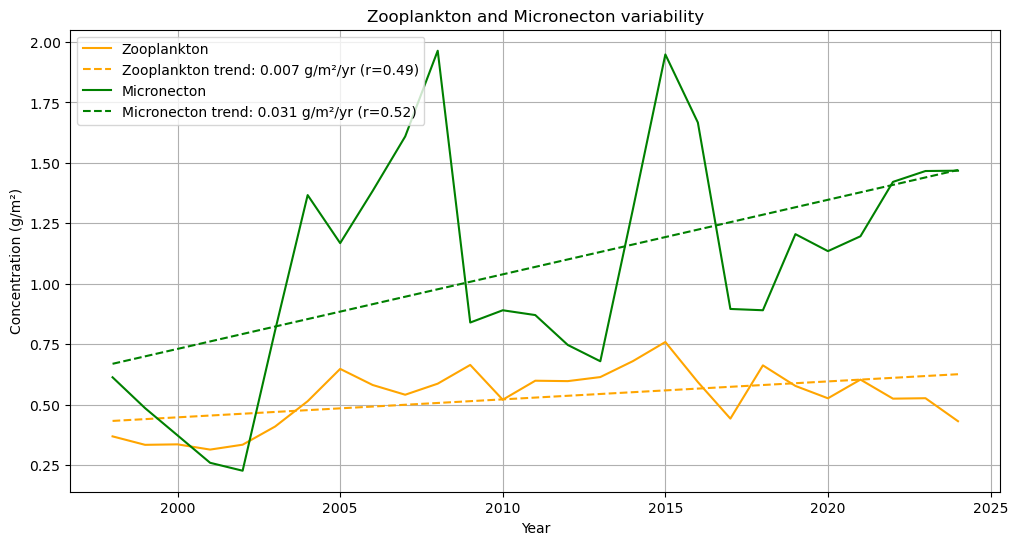

In [ ]:

# Plot
plt.figure(figsize=(12,6))
plt.plot(zooc_yearly_mean.year.data, zooc_yearly_mean.data, color='orange', label='Zooplankton')
plt.plot(zooc_yearly_mean.year.data, trend_z, linestyle='--', color='orange', label=f"Zooplankton trend: {slope_z:.3f} g/m²/yr (r={r_z:.2f})")

plt.plot(necton_yearly_mean.year.data, necton_yearly_mean.data, color='green', label='Micronekton')
plt.plot(necton_yearly_mean.year.data, trend_n, linestyle='--', color='green', label=f"Micronekton trend: {slope_n:.3f} g/m²/yr (r={r_n:.2f})")

plt.xlabel("Year")
plt.ylabel("Concentration (g/m²)")
plt.title("Zooplankton and Micronekton variability")
plt.legend()
plt.grid(True)
plt.show()
